In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
df = pd.read_csv('C:\\Users\\hp\\OneDrive\\ML experiments\\resume_dataset.csv')

In [110]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad..."


In [111]:
df.columns

Index(['Category', 'Resume'], dtype='object')

In [ ]:
df.shape

(169, 2)

In [117]:
df['Category'].value_counts()

Category
Java Developer               14
Database                     11
HR                           11
Data Science                 10
Advocate                     10
Automation Testing            7
DevOps Engineer               7
Testing                       7
DotNet Developer              7
Hadoop                        7
SAP Developer                 6
Python Developer              6
Health and fitness            6
Civil Engineer                6
Arts                          6
Business Analyst              6
Web Designing                 5
Mechanical Engineer           5
Sales                         5
ETL Developer                 5
Electrical Engineering        5
Blockchain                    5
Network Security Engineer     5
Operations Manager            4
PMO                           3
Name: count, dtype: int64

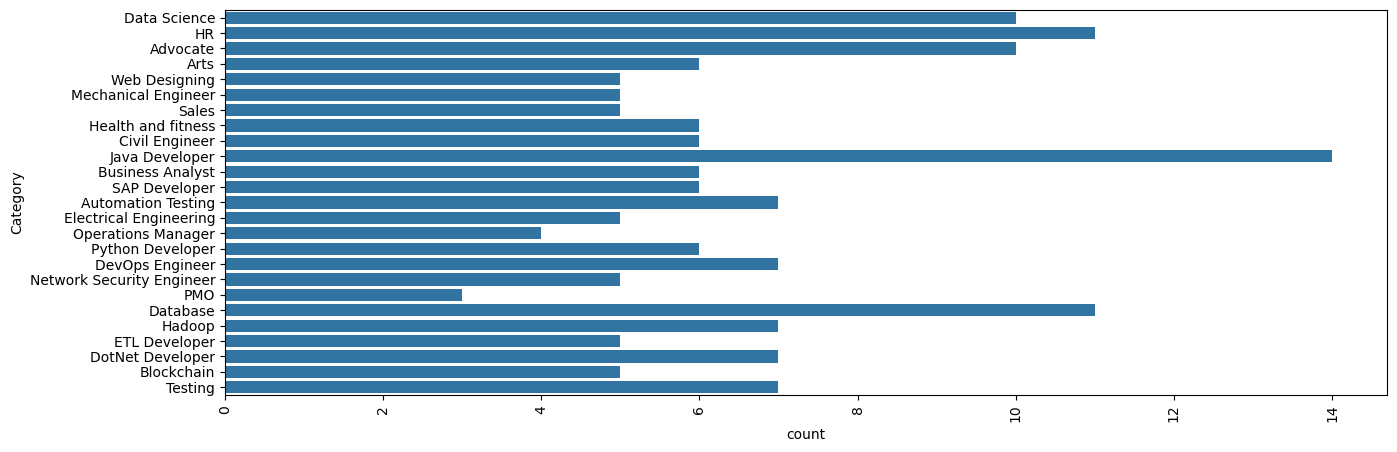

In [118]:
plt.figure(figsize = (15,5))
sns.countplot(df['Category'])
plt.xticks(rotation=90)
plt.show()

In [119]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

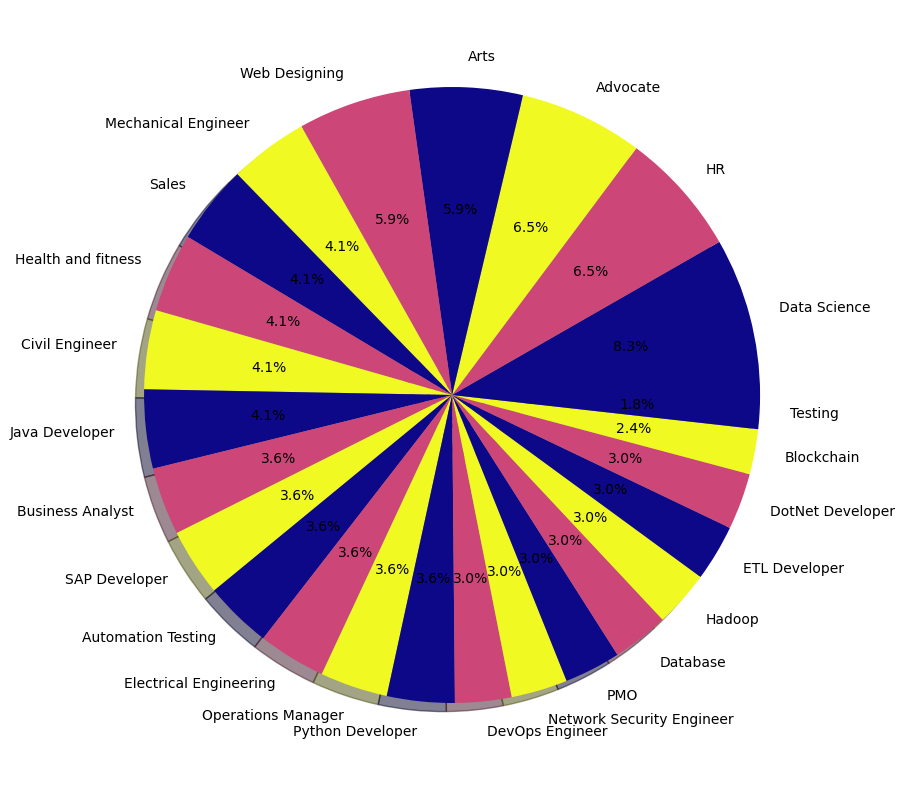

In [120]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize = (15,10))
plt.pie(counts,labels=labels,autopct='%1.1f%%',shadow = True, colors = plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

In [121]:
df['Category'][0]

'Data Science'

In [123]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \nData Science Assurance AssociateData Science Assurance Associate - Ernst & Young LLPSkill Details \nJAVASCRIPT- Exprience - 24 months\njQuery- Exprience - 24 months\nPython- Exprience - 24 monthsCompany Details \ncompany - Ernst & Young LLP\ndescription - Fraud Investigations and Dispute Services   Ass

In [124]:
import re
def CleanResume(txt):
    cleanTxt = re.sub('http\S+\s',' ',txt)
    cleanTxt = re.sub('@\S+',' ',cleanTxt)
    cleanTxt = re.sub('#\S+\s',' ',cleanTxt)
    cleanTxt = re.sub('RT|cc',' ',cleanTxt)
    cleanTxt = re.sub('[%s]'%re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""),' ',cleanTxt)
    cleanTxt = re.sub(r'[^\x00-\x7f]',' ',cleanTxt)
    cleanTxt = re.sub('\s+',' ',cleanTxt)
    return cleanTxt

    

In [126]:
df['Resume'] = df['Resume'].apply(lambda x: CleanResume(x))

In [127]:
df['Resume'][0]

'Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance AssociateData Science Assurance Associate Ernst Young LLPSkill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in a elerating the re

In [128]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [129]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

In [130]:
df.Category.unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [131]:
#['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
#      'Mechanical Engineer', 'Sales', 'Health and fitness',
#       'Civil Engineer', 'Java Developer', 'Business Analyst',
#      'SAP Developer', 'Automation Testing', 'Electrical Engineering',
#      'Operations Manager', 'Python Developer', 'DevOps Engineer',
#      'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
#      'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
#     dtype=object)

In [132]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english', max_features = 10000, ngram_range = (1,3), sublinear_tf = True, min_df = 1)
tfidf.fit(df['Resume'])
RequiredText = tfidf.transform(df['Resume'])

In [133]:
from sklearn.model_selection import train_test_split

In [134]:
X_train, X_test, y_train, y_test = train_test_split(RequiredText, df['Category'], test_size = 0.2, random_state = 42, stratify=df['Category'])

In [135]:
X_train.shape

(135, 10000)

In [136]:
X_test.shape

(34, 10000)

In [137]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

# Create a pipeline to reduce dimensions and then classify
# LinearSVC is generally much faster for 40k+ features
model = Pipeline([
    ('model',OneVsRestClassifier(LinearSVC(C = 10, max_iter = 10000)))
])
model.fit(X_train,y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test,ypred))

0.8235294117647058


In [138]:
ypred

array([22,  2, 15, 17, 14,  7, 10, 20,  7, 18, 15,  5, 12,  6, 13,  3, 18,
       24, 14,  0,  2,  6, 11,  2, 15,  0, 21,  9, 12, 20,  2,  1, 16, 13])

In [139]:
import os
os.makedirs("models", exist_ok=True)

In [140]:
import pickle
pickle.dump(tfidf, open(r"C:\Users\hp\OneDrive\Documents\Resume Screening with Python\models\tfidf.pkl","wb"))
pickle.dump(model, open(r"C:\Users\hp\OneDrive\Documents\Resume Screening with Python\models\clf.pkl","wb"))
pickle.dump(le, open(r"C:\Users\hp\OneDrive\Documents\Resume Screening with Python\models\label_encoder.pkl","wb"))
print("Saved successfully")

Saved successfully


In [141]:
import pickle

# Load the trained classifier
model = pickle.load(open('models/clf.pkl','rb'))

# Clean the input resume
cleaned_resume = CleanResume('txt')

# Transform the cleaned resume using the trained TfidfVectorizer
input_features = tfidf.transform([cleaned_resume])

# Make the prediction using the Loaded classifier
prediction_id = model.predict(input_features)[0]

# Map category ID to category name
category_mapping = {
    6: 'Data Science',  
    12: 'HR', 
    0: 'Advocate', 
    1: 'Arts', 
    24: 'Web Designing',  
    16: 'Mechanical Engineer', 
    22: 'Sales', 
    14: 'Health and fitness', 
    5: 'Civil Engineer', 
    15: 'Java Developer', 
    4: 'Business Analyst',  
    21: 'SAP Developer', 
    2: 'Automation Testing',  
    11: 'Electrical Engineering', 
    18: 'Operations Manager',  
    20: 'Python Developer', 
    8: 'DevOps Engineer',   
    17: 'Network Security Engineer', 
    19: 'PMO',  
    7: 'Database',  
    13: 'Hadoop',  
    10: 'ETL Developer', 
    9: 'DotNet Developer',
    3: 'Blockchain',
    23: 'Testing'
}

category_name = category_mapping.get(prediction_id, "Unknown")
print("Predicted Category", category_name)
print(prediction_id)
print(type(model))

Predicted Category DotNet Developer
9
<class 'sklearn.pipeline.Pipeline'>


In [142]:
import pickle

model = pickle.load(open('models/clf.pkl','rb'))

print(model.named_steps)

{'model': OneVsRestClassifier(estimator=LinearSVC(C=10, max_iter=10000))}


In [143]:
import pickle

m = pickle.load(
    open(
        r"C:\Users\hp\OneDrive\Documents\Resume Screening with Python\models\clf.pkl",
        "rb"
    )
)

print(m.named_steps.keys())

dict_keys(['model'])


In [144]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\hp
['.anaconda', '.bash_history', '.conda', '.condarc', '.continuum', '.copilot', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.packettracer', '.vscode', '.vscode-insiders', '.vscode-shared', '0103CS231309', '16.py', 'aayushi.py', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'bouncing_ball.py', 'c language practice by raghav', 'Cisco Packet Tracer 9.0.0', 'clf.pkl', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'models', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{bb8b8b29-2f17-11f0-967e-c99620fd6b53}.TM.blf', 'NTUSER.DAT{bb8b8b29-2f17-11f0-967e-c99620fd6b53}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{bb8b8b29-2f17-11f0-967e-c99620fd6b53}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'python', 'QUIZ.ipynb', 'Recent', 'Resume Screening with Python.ipynb',

In [145]:
import os

print("Files inside models folder:")
print(os.listdir("models"))

print("clf.pkl size:", os.path.getsize("models/clf.pkl"))
print("tfidf.pkl size:", os.path.getsize("tfidf.pkl"))

print("label_encoder.pkl exists:",
      os.path.exists("label_encoder.pkl"))

print("models/label_encoder.pkl exists:",
      os.path.exists("models/label_encoder.pkl"))

Files inside models folder:
['clf.pkl', 'label_encoder.pkl', 'tfidf.pkl']
clf.pkl size: 1926124
tfidf.pkl size: 240238594
label_encoder.pkl exists: False
models/label_encoder.pkl exists: True


In [146]:
import os

print(os.path.getsize("models/clf.pkl"))
print(os.path.getsize("models/tfidf.pkl"))
print(os.path.getsize("models/label_encoder.pkl"))

1926124
413555
537


In [97]:
import sklearn
print(sklearn.__version__)

1.6.1


In [98]:
import os
print(os.path.exists("models/clf.pkl"))

True


In [99]:
import pickle

m = pickle.load(open("models/clf.pkl","rb"))

print(m.named_steps.keys())

dict_keys(['model'])


In [100]:
import os

print(os.getcwd())

C:\Users\hp


In [101]:
import os

print(os.path.abspath("models/clf.pkl"))

C:\Users\hp\models\clf.pkl


In [102]:
import os
print("Notebook folder:", os.getcwd())
print("clf path:", os.path.abspath("models/clf.pkl"))

Notebook folder: C:\Users\hp
clf path: C:\Users\hp\models\clf.pkl
